In [7]:
#Helper functions
def move_pt(om, T):
    return (om * T) % (2 * np.pi)

def dst(r1, th1, r2, th2):
    return ((r1*np.cos(th1)-r2*np.cos(th2))**2 + (r1*np.sin(th1)-r2*np.sin(th2))**2)**0.5

#simple loss function for satellite-ground station link
def eta(L, h, r, R, eff):
    lam = 810e-9;
    eta_zen = 0.5;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    eta_atm2 = eta_zen**secZ;

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eta_atm2 * eff;
    
    return efficiency

In [14]:
#double-downlink scenario Bell test shadow of a Polar satellite
#GS1 and GS2 are placed symmetrically (mirror image about the satellite longitude).
#Can be modified to fix GS1 just below the satellite (or some other fixed point) and then only vary GS2. 

from joblib import Parallel, delayed
import numpy as np
import math as m
from numpy import linalg as LA
import random
import matplotlib.pyplot as plt
import time 


#constants
c = 2.9978e8
R = 6371e3
h = 500e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600
pair_rate = 1e7


def generate_point(R,theta,phi):
    return [R*np.sin(theta)*np.cos(phi),R*np.sin(theta)*np.sin(phi),R*np.cos(theta)]

def dst(a, b):
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5

def bellsshadow(lat,long,T,bkg_rate1,bkg_rate2): 
    
    #shadow plot code
    dt = 1/pair_rate
    
    steps = m.floor(T/dt)
    tarray = np.array([i*dt for i in range(steps)])

    #trajectory

    r_gs = R
    r_sat = R+h
    
    sat = generate_point(r_sat, 90*np.pi/180, 0)
    gs1 = generate_point(r_gs, lat, -long)
    gs2 = generate_point(r_gs, lat, long)
    dist1 = dst(sat,gs1)
    dist2 = dst(sat,gs2)

    #basis and spin data points

    a1b1=np.array([0])
    a2b1=np.array([0])
    a1b2=np.array([0])
    a2b2=np.array([0])
    
    #naming each basis

    a1=1
    a2=2
    b1=3
    b2=4
    up=1
    dn=-1

    #basis

    sz=np.array([[1,0],[0,-1]])
    sx=np.array([[0,1],[1,0]])
    B=(-1/m.sqrt(2))*(sz+sx)
    Bb=(1/m.sqrt(2))*(sz-sx) #B prime

    #eigen values and vectors 

    a1va, A1 = LA.eig(sz)
    idx=np.argsort(a1va)
    a1va=a1va[idx]
    A1=A1[:,idx]
    a2va, A2 = LA.eig(sx)
    idx=np.argsort(a2va)
    a2va=a2va[idx]
    A2=A2[:,idx]
    b1va, B1 = LA.eig(B)
    idx=np.argsort(b1va)
    b1va=b1va[idx]
    B1=B1[:,idx]
    b2va, B2 = LA.eig(Bb)
    idx=np.argsort(b2va)
    b2va=b2va[idx]
    B2=B2[:,idx]

    #naming each eigen vector

    a1p=A1[:,1]
    a1n=A1[:,0]
    a2p=A2[:,1]
    a2n=A2[:,0]
    b1p=B1[:,1]
    b1n=B1[:,0]
    b2p=B2[:,1]
    b2n=B2[:,0]

    #probabilities

    a1b1pp=(np.dot(b1p,a1n))**2 
    a1b1nn=(np.dot(b1n,a1p))**2
    a1b2pp=(np.dot(b2p,a1n))**2
    a1b2nn=(np.dot(b2n,a1p))**2
    a2b1pp=(np.dot(b1p,a2n))**2
    a2b1nn=(np.dot(b1n,a2p))**2
    a2b2pp=(np.dot(b2p,a2n))**2
    a2b2nn=(np.dot(b2n,a2p))**2

   
        
    for t in range(steps):
        #gs-sat correlation
        eff_gs_sat1 = eta(dist1, h, 0.1, 0.6, 0.5)
        eff_gs_sat2 = eta(dist1, h, 0.1, 0.6, 0.5)
        
        abasis=random.choice([a1,a2]) #50-50 chance basis
        bbasis=random.choice([b1,b2]) #50-50 chance basis
        
        r1 = random.random()
        r2 = random.random()
        r_b = random.random()
        
        #background noise + dark counts
        if (r_b < dt*bkg_rate1 and r2 < eff_gs_sat2) or (r_b < dt*bkg_rate2 and r1 < eff_gs_sat1):
            print("noiseeee")
            aspin = random.choice([up,dn])
            bspin = random.choice([up,dn])
            if bbasis == b1 and abasis == 1:
                a1b1=np.append(a1b1,[(aspin*bspin)])
            if bbasis == b1 and abasis == 2:
                a2b1=np.append(a2b1,[(aspin*bspin)])
            if bbasis == b2 and abasis == 1: 
                a1b2=np.append(a1b2,[(aspin*bspin)])
            if bbasis == b2 and abasis == 2: 
                a2b2=np.append(a2b2,[(aspin*bspin)])
        
        else: #keeping count of lost photons
            if (r_b < dt*bkg_rate1 and r2 > eff_gs_sat2) or (r_b < dt*bkg_rate2 and r1 > eff_gs_sat1):
                if bbasis == b1 and abasis == 1:
                    a1b1=np.append(a1b1,0)
                if bbasis == b1 and abasis == 2:
                    a2b1=np.append(a2b1,0)
                if bbasis == b2 and abasis == 1: 
                    a1b2=np.append(a1b2,0)
                if bbasis == b2 and abasis == 2: 
                    a2b2=np.append(a2b2,0)
        
            #correlated photons
            else:
                if r1<=eff_gs_sat1 and r2<eff_gs_sat2:
                    print("correlated")
                    aspin=random.choice([up,dn]) #50 chance spin
#                     print([dist1,dist2,eff_gs_sat1,eff_gs_sat2])

                    if bbasis == b1:
                        if abasis==1:
                            if aspin==up:
                                if random.random()<=(a1b1pp):
                                    bspin=up
                                    a1b1=np.append(a1b1,[(aspin*bspin)])
                                else:
                                    bspin=dn
                                    a1b1=np.append(a1b1,[(aspin*bspin)])
                            if aspin==dn:
                                if random.random()<=(a1b1nn):
                                    bspin=dn
                                    a1b1=np.append(a1b1,[(aspin*bspin)])
                                else:
                                    bspin=up
                                    a1b1=np.append(a1b1,[(aspin*bspin)])
                        if abasis==2:
                            if aspin==up:
                                if random.random()<=(a2b1pp):
                                    bspin=up
                                    a2b1=np.append(a2b1,[(aspin*bspin)])
                                else:
                                    bspin=dn
                                    a2b1=np.append(a2b1,[(aspin*bspin)])
                            if aspin==dn:
                                if random.random()<=(a2b1nn):
                                    bspin=dn
                                    a2b1=np.append(a2b1,[(aspin*bspin)])
                                else:
                                    bspin=up
                                    a2b1=np.append(a2b1,[(aspin*bspin)])
                    if bbasis == b2:
                        if abasis==1:
                            if aspin==up:
                                if random.random()<=(a1b2pp):
                                    bspin=up
                                    a1b2=np.append(a1b2,[(aspin*bspin)])
                                else:
                                    bspin=dn
                                    a1b2=np.append(a1b2,[(aspin*bspin)])
                            if aspin==dn:
                                if random.random()<=(a1b2nn):
                                    bspin=dn
                                    a1b2=np.append(a1b2,[(aspin*bspin)])
                                else:
                                    bspin=up
                                    a1b2=np.append(a1b2,[(aspin*bspin)])
                        if abasis==2:
                            if aspin==up:
                                if random.random()<=(a2b2pp):
                                    bspin=up
                                    a2b2=np.append(a2b2,[(aspin*bspin)])
                                else:
                                    bspin=dn
                                    a2b2=np.append(a2b2,[(aspin*bspin)])
                            if aspin==dn:
                                if random.random()<=(a2b2nn):
                                    bspin=dn
                                    a2b2=np.append(a2b2,[(aspin*bspin)])
                                else:
                                    bspin=up
                                    a2b2=np.append(a2b2,[(aspin*bspin)])


                #one partner lost
                else:
#                     print("hello, one partner lost with no bkg")
                    if bbasis == b1 and abasis == 1:
                        a1b1=np.append(a1b1,0)
                    if bbasis == b1 and abasis == 2:
                        a2b1=np.append(a2b1,0)
                    if bbasis == b2 and abasis == 1: 
                        a1b2=np.append(a1b2,0)
                    if bbasis == b2 and abasis == 2: 
                        a2b2=np.append(a2b2,0)

    E11=(sum(a1b1))/max(1,len(np.nonzero(a1b1)[0])) #expectation of measurement outcomes when we measured in A,B basis
    E21=(sum(a2b1))/max(1,len(np.nonzero(a2b1)[0])) #expectation of measurement outcomes when we measured in A',B basis
    E12=(sum(a1b2))/max(1,len(np.nonzero(a1b2)[0])) #expectation of measurement outcomes when we measured in A,B' basis
    E22=(sum(a2b2))/max(1,len(np.nonzero(a2b2)[0])) #expectation of measurement outcomes when we measured in A',B' basis
    
    S=abs(E11+E21-E12+E22)   #CHSH number
 
    return S

In [15]:
#shadow for a given position of satellite.

n_runs = 30
n_jobs = 30
bkg_rate1 = 1e3
bkg_rate2 = 1e3
for T in [0.01]:
    
    shadow = np.zeros([180,180])
    S_mean = []
    S_std = []
    print(T)
    i=-1
    for lat in np.linspace(0,180,180):
        i+=1
        j=-1
        print(lat)
        if lat==90:
            lat+=0.05
        for long in np.linspace(-180,180,180):
            j+=1
            lat_rad = lat*np.pi/180 
            long_rad = long*np.pi/180
            r_gs = R
            r_sat = R+h

            sat = generate_point(r_sat, 90*np.pi/180, 0)
            gs = generate_point(r_gs, lat_rad, long_rad)
            cos_ang = np.dot(np.subtract(sat,gs),gs)/np.linalg.norm(gs)/np.linalg.norm(np.subtract(sat,gs)) 
    #         print(cos_ang)
            if cos_ang > 1e-10: #visibility condition
                t0 = time.time()
                S = Parallel(n_jobs=n_jobs)(delayed(bellsshadow)(lat_rad, long_rad, T, bkg_rate1, bkg_rate2) for i in range(n_runs))
                S_mean.append(np.mean(S))
                S_std.append(np.std(S))
                # print([np.mean(S), np.std(S)])
#                 print(time.time()-t0)

                if np.mean(S)-np.std(S)>2:
                    shadow[i][j] = 1
                    # print('hello')
            else:
                S_mean.append(0)
                S_std.append(0)
                
    np.save('bell_shadow_dd'+str(T)+'.npy', shadow)


0.01
0.0
1.005586592178771
2.011173184357542
3.016759776536313
4.022346368715084
5.027932960893855
6.033519553072626
7.039106145251397
8.044692737430168
9.050279329608939
10.05586592178771
11.061452513966481
12.067039106145252
13.072625698324023
14.078212290502794
15.083798882681565
16.089385474860336
17.09497206703911
18.100558659217878
19.106145251396647
20.11173184357542
21.117318435754193
22.122905027932962
23.12849162011173
24.134078212290504
25.139664804469277
26.145251396648046
27.150837988826815
28.156424581005588
29.16201117318436
30.16759776536313
31.1731843575419
32.17877094972067
33.184357541899445
34.18994413407822
35.19553072625698
36.201117318435756
37.20670391061453
38.212290502793294
39.21787709497207
40.22346368715084
41.22905027932961
42.234636871508386
43.24022346368715
44.245810055865924
45.2513966480447
46.25698324022346
47.262569832402235
48.26815642458101
49.27374301675978
50.27932960893855
51.28491620111732
52.29050279329609
53.296089385474865
54.30167597765363

KeyboardInterrupt: 

In [7]:
# SV = np.load('visibility.npy') #visibility shadow can be obtained by removing the Bell test condition from the previous Kernel.
SS = np.load('bell_shadow_dd'+str(T)+'.npy')

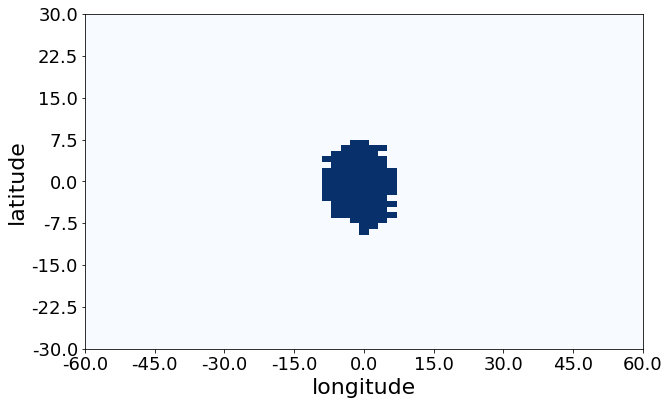

In [8]:
#plotting the (symmetric) double-downlink Bell shadow

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=None)
ax.set_xlim([60,120])
ax.set_ylim([60,120])

ax.imshow(SS, alpha=1, cmap='Blues')


plt.xticks(np.linspace(60,120,9), np.linspace(-60,60,9), fontsize=18)
plt.yticks(np.linspace(60,120,9), np.linspace(-30,30,9), fontsize=18)

ratio = 0.6
xleft, xright = ax.get_xlim()
ybottom, ytop = ax.get_ylim()
ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

plt.xlabel('longitude', fontsize=22)
plt.ylabel('latitude', fontsize=22)

plt.savefig('bell_shadow_dd_10ms.png', bbox_inches="tight")